In [3]:
import os
from datetime import datetime
from typing import Dict, Union
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import torch
from azureml.core import Workspace, Dataset, Datastore

In [1]:

EXPOSURE_PATH = "p1_postop/SSL/exposure/preop.csv"
OUTCOME_PATH = "p1_postop/SSL/targets/MORTALITY.csv"
MAPPING_PATH = "Zahra/Data-07-2025/MD/PreMEDS/hash_to_integer_map.pkl"     # در واقع داده ها همون داده ها هستن!‌نیازی نبوده که از داده های جدیدتر استفاده بشه چون فاز Premeds یکسانه
DATASTORE_NAME = "researcher_data"

# Azure ML workspace configuration
SUBSCRIPTION_ID = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
RESOURCE_GROUP = 'forskerpl-n0ybkr-rg'
WORKSPACE_NAME = 'forskerpl-n0ybkr-mlw'

TIMESTAMP_COL = 'time'
ABSPOS_COL = 'abspos'
PID_COL = 'subject_id'
MANDATORY_COLUMNS = [TIMESTAMP_COL, PID_COL]


In [4]:
def get_workspace() -> Workspace:
    return Workspace(
        subscription_id=SUBSCRIPTION_ID,
        resource_group=RESOURCE_GROUP,
        workspace_name=WORKSPACE_NAME
    )

# -------------------
# Load CSV from Datastore
# -------------------
def read_csv_from_datastore(
    ws: Workspace,
    datastore_name: str,
    csv_path: str,
    rename_dict: Dict[str, str] = None,
    local_dir: str = "./temp_data"
) -> pd.DataFrame:
    os.makedirs(local_dir, exist_ok=True)
    datastore = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((datastore, csv_path))
    file_paths = dataset.download(target_path=local_dir, overwrite=True)
    df = pd.read_csv(file_paths[0])
    if rename_dict:
        df = df.rename(columns=rename_dict)
    return df


# -------------------
# Load PyTorch Mapping File from Datastore
# -------------------

def load_mapping_from_datastore_file(
    ws: Workspace,
    datastore_name: str,
    file_path: str,
    local_dir: str = "./temp_data"
) -> Dict[str, int]:
    os.makedirs(local_dir, exist_ok=True)
    datastore = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((datastore, file_path))
    downloaded_files = dataset.download(target_path=local_dir, overwrite=True)
    
    local_path = downloaded_files[0]
    
    with open(local_path, "rb") as f:
        mapping = pickle.load(f)
    
    return mapping
# -------------------
# Data Cleaning Utilities
# -------------------
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    if all(col in df.columns for col in MANDATORY_COLUMNS):
        df = df.dropna(subset=MANDATORY_COLUMNS, how="any")
    df = df.drop_duplicates()
    return df


def get_hours_since_epoch(timestamps: Union[pd.Series, datetime]) -> Union[pd.Series, float]:
    if isinstance(timestamps, pd.Series):
        if len(timestamps) == 0:
            return pd.Series([], dtype=float)
        timestamps = pd.to_datetime(timestamps, utc=True, errors="coerce").dt.tz_localize(None)
        seconds = timestamps.view("int64") // 10**9  # ✅ بدون اخطار در پانداس جدید
        hours = seconds / 3600
        return hours
    else:
        ts = pd.to_datetime(timestamps, utc=True).tz_localize(None)
        return (ts.value // 10**9) / 3600

def map_pids_to_ints(df: pd.DataFrame, pid_map: Dict[str, int]) -> pd.DataFrame:
    df[PID_COL] = df[PID_COL].astype(str).map(pid_map)
    df = df.dropna(subset=[PID_COL])
    df = df.copy()
    df.loc[:, PID_COL] = df[PID_COL].astype(int)
    return df





In [5]:

# -------------------
# OOT - Fine tune - 2021 - 2022
# -------------------
from datetime import datetime

def filter_by_date_range(
    df: pd.DataFrame,
    start_date: str,
    end_date: str,
    timestamp_col: str,
    name: str = "DataFrame",
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Filters the DataFrame to only include rows where timestamp_col is between start_date (inclusive)
    and end_date (exclusive). Prints useful stats if verbose=True.
    
    Args:
        df: Input DataFrame
        start_date: Start date (inclusive), in 'YYYY-MM-DD'
        end_date: End date (exclusive), in 'YYYY-MM-DD'
        timestamp_col: Name of the column containing timestamps
        name: Optional name to show in printed output
        verbose: Whether to print summary info

    Returns:
        Filtered DataFrame
    """
    df = df.copy()
    original_len = len(df)
    print(f"\n[DEBUG] {name} - Sample values in '{timestamp_col}':")
    print(df[timestamp_col].dropna().astype(str).unique()[:5])
    print(f"[DEBUG] {name} - dtype of '{timestamp_col}': {df[timestamp_col].dtype}")

    # Parse dates
    df["parsed_time"] = pd.to_datetime(df[timestamp_col], utc=True, errors="coerce")
    start = pd.to_datetime(start_date).tz_localize("UTC")
    end = pd.to_datetime(end_date).tz_localize("UTC")
    
    # Filter
    df_filtered = df[
        (df["parsed_time"] >= start) & 
        (df["parsed_time"] < end)
    ].drop(columns=["parsed_time"])

    # Verbose print
    if verbose:
        print(f"\n========== {name} Filtering Report ==========")
        print(f"Total rows before filtering: {original_len}")
        print(f"Total rows after filtering:  {len(df_filtered)}")
        print(f"Rows removed:                {original_len - len(df_filtered)}")
        if len(df_filtered) > 0:
            parsed_times = pd.to_datetime(df_filtered[timestamp_col], utc=True)
            print("\nFirst 3 timestamps after filtering:")
            print(parsed_times.sort_values().head(3).dt.strftime('%Y-%m-%d %H:%M:%S %Z'))
            print("\nLast 3 timestamps after filtering:")
            print(parsed_times.sort_values().tail(3).dt.strftime('%Y-%m-%d %H:%M:%S %Z'))
            print(f"\nDate range after filtering:")
            print(f"Min: {parsed_times.min()}")
            print(f"Max: {parsed_times.max()}")
        else:
            print("\n No data left after filtering.")

    return df_filtered

In [6]:
def plot_monthly_distribution(df, timestamp_col, title, color):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import pandas as pd

    df = df.copy()
    df['month'] = pd.to_datetime(df[timestamp_col]).dt.to_period('M').dt.to_timestamp()
    monthly_counts = df['month'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(monthly_counts.index, monthly_counts.values, color=color, width=20)

    # فقط سال یا هر چند ماه یک‌بار برچسب بزن
    if len(monthly_counts) > 36:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


In [7]:
if __name__ == "__main__":
    ws = get_workspace()

In [8]:
if __name__ == "__main__":
    # -------------------
    # Reading Data
    # -------------------
    exposure = read_csv_from_datastore(
        ws,
        datastore_name=DATASTORE_NAME,
        csv_path=EXPOSURE_PATH,
        rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
    )
    print ("Exposure:",len(exposure))

    outcome = read_csv_from_datastore(
        ws,
        datastore_name=DATASTORE_NAME,
        csv_path=OUTCOME_PATH,
        rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
    )
    print ("Outcome:",len(outcome))


Timeout was exceeded in force_flush().
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
Exposure: 767161
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
Outcome: 9531


In [10]:
if __name__ == "__main__":
    # -------------------
    # Clean Data
    # -------------------
    exposure = clean_data(exposure)
    outcome = clean_data(outcome)

    print(" Raw exposure TIMESTAMP samples:")
    print(exposure.head(10))
    print(exposure.dtypes)
    print ("Exposure:",len(exposure))

    print("\n Raw outcome TIMESTAMP samples:")
    print(outcome.head(10))
    print(outcome.dtypes)
    print ("Outcome:",len(outcome))


 Raw exposure TIMESTAMP samples:
                                          subject_id        time  abspos
0  88572797278B2604219A1962B005B801289909140F1CA7...  2016-05-24  -32208
1  A34E5948E6C23BDED4FCD553D0BC34649EE22759D15454...  2016-06-22  -31512
2  E8B62CFB71809D901D1F101BFE66F5EB2DD1718227E698...  2016-11-05  -28248
3  F3046580D734B72A9297A8D2F78D0C32DEFB51ED1B71E0...  2016-11-05  -28248
4  E11AAAD876434636E91090720629285F45E1F3988CA7AB...  2016-11-07  -28200
5  B8D182E9A64ABD5B53218D83FB56AA3E7DD59FC4807BA7...  2016-11-05  -28248
6  6042880BEEFBB68CF9EE07F7C6A419C65BFD5C19F28DF7...  2016-11-06  -28224
7  D12E8673ABC04698C867C8D10AACB99F68C67AA503312A...  2016-11-07  -28200
8  DBFC4230A8F61C1A4F34CA6CC9D869370591EDB3937460...  2017-05-17  -23616
9  D4F831B72C442EF0E5074E47F029E0B45655AB9563A3DF...  2016-11-08  -28176
subject_id    object
time          object
abspos         int64
dtype: object
Exposure: 767161

 Raw outcome TIMESTAMP samples:
                                     


========== STEP 5: Plot Monthly Distributions ==========


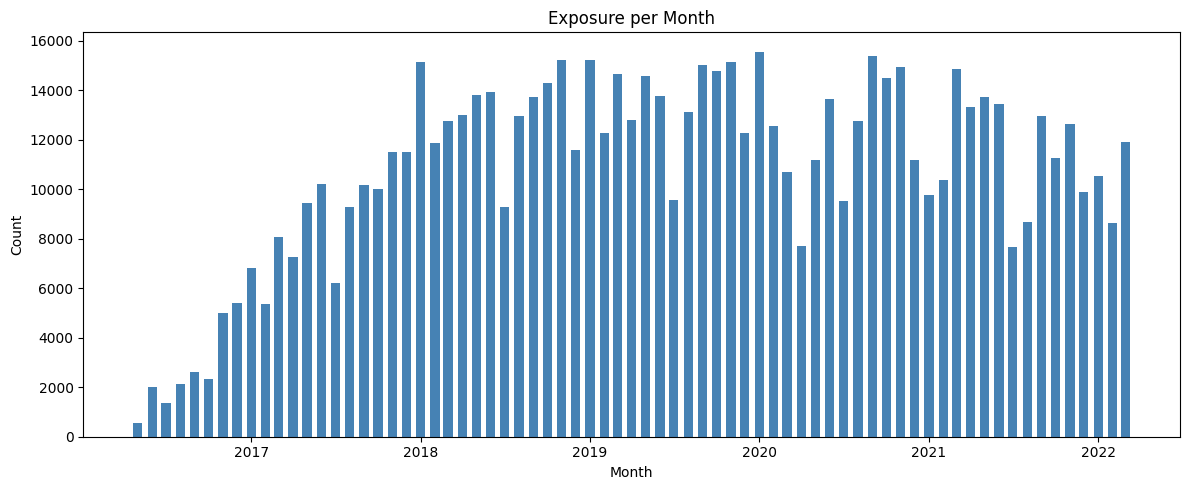

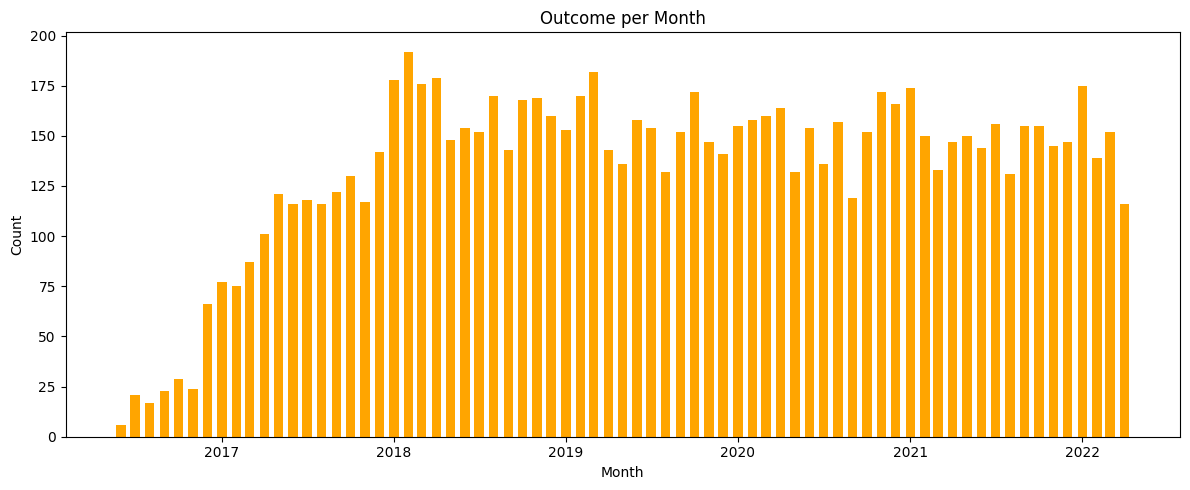

In [18]:
if __name__ == "__main__":
    ### STEP 5: Visualize Monthly Distributions
    print("\n========== STEP 5: Plot Monthly Distributions ==========")
    
    # Plot for Exposure
    plot_monthly_distribution(exposure, TIMESTAMP_COL, title="Exposure per Month", color="steelblue")

    # Plot for Outcome
    plot_monthly_distribution(outcome, TIMESTAMP_COL, title="Outcome per Month", color="orange")


In [11]:
if __name__ == "__main__":
    # -------------------
    # Load Mapping file
    # -------------------
    pid_map = load_mapping_from_datastore_file(
        ws,
        datastore_name=DATASTORE_NAME,
        file_path=MAPPING_PATH
    )


{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}


In [12]:
if __name__ == "__main__":
    ## ----------
    # OOT 
    ##----------

    # STEP 4: Time-based Filtering for OOT (2020–2021)
    print("\n========== STEP 4: Time-based Filtering (2020-01-02 to 2021-06-01) ==========")

    # فیلتر Exposure
    exposure = filter_by_date_range(
        exposure,
        start_date="2021-06-01",                   
        end_date="2022-04-1",
        timestamp_col=TIMESTAMP_COL,
        name="Exposure"
    )
    #Finetune   #       "2020-01-02"   --- "2021-06-01"

    # فیلتر Outcome
#    outcome = filter_by_date_range(
#        outcome,
#        start_date="2020-01-02",
#        end_date="2022-01-01",
#        timestamp_col=TIMESTAMP_COL,
#        name="Outcome"
#    )



========== STEP 4: Time-based Filtering (2020-01-02 to 2021-06-01) ==========

[DEBUG] Exposure - Sample values in 'time':
['2016-05-24' '2016-06-22' '2016-11-05' '2016-11-07' '2016-11-06']
[DEBUG] Exposure - dtype of 'time': object

========== Exposure Filtering Report ==========
Total rows before filtering: 767161
Total rows after filtering:  107672
Rows removed:                659489

First 3 timestamps after filtering:
648418    2021-06-01 00:00:00 UTC
655983    2021-06-01 00:00:00 UTC
651370    2021-06-01 00:00:00 UTC
Name: time, dtype: object

Last 3 timestamps after filtering:
735003    2022-03-31 00:00:00 UTC
743384    2022-03-31 00:00:00 UTC
749650    2022-03-31 00:00:00 UTC
Name: time, dtype: object

Date range after filtering:
Min: 2021-06-01 00:00:00+00:00
Max: 2022-03-31 00:00:00+00:00


In [25]:

    # فیلتر Outcome
    outcome = filter_by_date_range(
        outcome,
        start_date="2020-01-02",
        end_date="2021-06-01",
        timestamp_col=TIMESTAMP_COL,
        name="Outcome"
    )


[DEBUG] Outcome - Sample values in 'time':
['2016-12-06' '2016-12-07' '2016-12-08' '2016-12-10' '2016-12-09']
[DEBUG] Outcome - dtype of 'time': object

========== Outcome Filtering Report ==========
Total rows before filtering: 9531
Total rows after filtering:  2574
Rows removed:                6957

First 3 timestamps after filtering:
5233    2020-01-02 00:00:00 UTC
5245    2020-01-02 00:00:00 UTC
5246    2020-01-02 00:00:00 UTC
Name: time, dtype: object

Last 3 timestamps after filtering:
7825    2021-05-30 00:00:00 UTC
7826    2021-05-31 00:00:00 UTC
7828    2021-05-31 00:00:00 UTC
Name: time, dtype: object

Date range after filtering:
Min: 2020-01-02 00:00:00+00:00
Max: 2021-05-31 00:00:00+00:00


In [13]:
print ("Exposure:",len(exposure))
print ("Outcome:",len(outcome))

Exposure: 107672
Outcome: 9531



========== STEP 5: Plot Monthly Distributions ==========


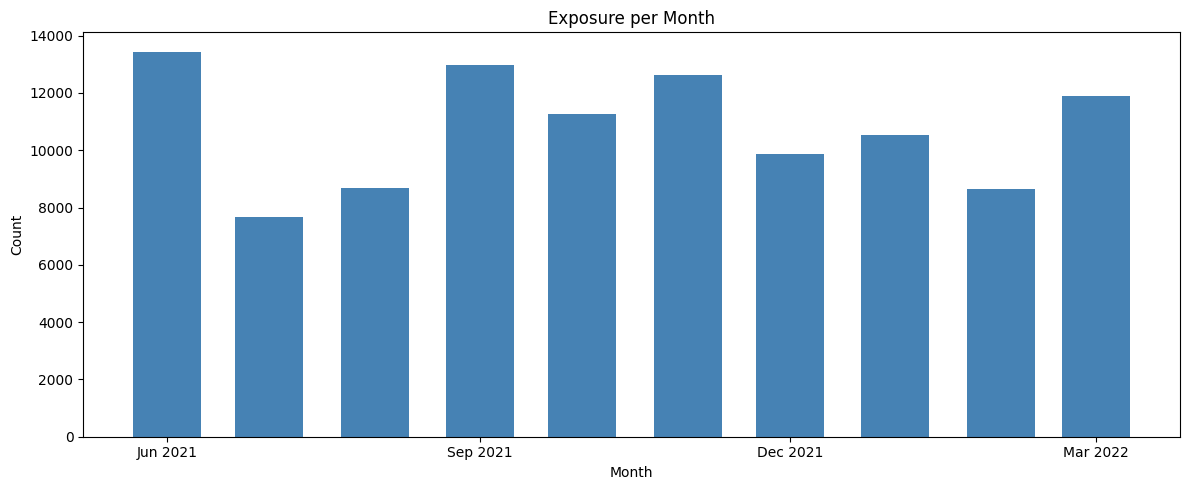

In [43]:
if __name__ == "__main__":
    ### STEP 5: Visualize Monthly Distributions
    print("\n========== STEP 5: Plot Monthly Distributions ==========")
    
    # Plot for Exposure
    plot_monthly_distribution(exposure, TIMESTAMP_COL, title="Exposure per Month", color="steelblue")


In [14]:
if __name__ == "__main__":
# -------------------
# Load Mapping file
# -------------------
    pid_map = load_mapping_from_datastore_file(
        ws,
        datastore_name=DATASTORE_NAME,
        file_path=MAPPING_PATH
    )
    # -------------------
# Map pids to ints
# -------------------

    exposure = map_pids_to_ints(exposure, pid_map)
    outcome = map_pids_to_ints(outcome, pid_map)
    

{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}


/tmp/ipykernel_22250/467222472.py:75: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df.loc[:, PID_COL] = df[PID_COL].astype(int)
/tmp/ipykernel_22250/467222472.py:75: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df.loc[:, PID_COL] = df[PID_COL].astype(int)


In [15]:
if __name__ == "__main__":
# -------------------
# Change Abspos col
# -------------------
    exposure[ABSPOS_COL] = get_hours_since_epoch(exposure[TIMESTAMP_COL]).astype(int)
    outcome[ABSPOS_COL] = get_hours_since_epoch(outcome[TIMESTAMP_COL]).astype(int)

    print("Exposure sample:")
    print(exposure.head())

    print("Outcome sample:")
    print(outcome.head())

Exposure sample:
       subject_id        time  abspos
16874     1854218  2021-10-01  453624
23823       84041  2021-09-27  453528
24664      173463  2021-11-19  454800
24874     1069968  2022-02-02  456600
24876      460234  2021-09-27  453528
Outcome sample:
   subject_id        time  abspos
0      354087  2016-12-06  411384
1      741296  2016-12-06  411384
2     1758393  2016-12-07  411408
3     2125517  2016-12-06  411384
4       80642  2016-12-06  411384


In [46]:
print ("Exposure:",len(exposure))
print ("Outcome:",len(outcome))

Exposure: 107621
Outcome: 9530


In [16]:
print ("Exposure:",len(exposure))
print ("Outcome:",len(outcome))

Exposure: 107621
Outcome: 9530


In [5]:

if __name__ == "__main__":
    ws = get_workspace()

# -------------------
# Reading Data
# -------------------
    exposure = read_csv_from_datastore(
        ws,
        datastore_name=DATASTORE_NAME,
        csv_path=EXPOSURE_PATH,
        rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
    )

    outcome = read_csv_from_datastore(
        ws,
        datastore_name=DATASTORE_NAME,
        csv_path=OUTCOME_PATH,
        rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
    )
# -------------------
# Clean Data
# -------------------
    exposure = clean_data(exposure)
    outcome = clean_data(outcome)

    print(" Raw exposure TIMESTAMP samples:")
    print(exposure.head(10))
    print(exposure.dtypes)

    print("\n Raw outcome TIMESTAMP samples:")
    print(outcome[TIMESTAMP_COL].head(10))
    print(outcome.dtypes)


## ----------
# OOT 
##----------

### STEP 4: Time-based Filtering for OOT (2020–2021)
    print("\n========== STEP 4: Time-based Filtering (2020-01-02 to 2022-01-01) ==========")

    # فیلتر کردن Exposure و چاپ گزارش
    exposure = filter_by_date_range(
        exposure,
        start_date="2020-01-02",
        end_date="2022-01-01",
        timestamp_col=TIMESTAMP_COL,
        name="Exposure"
    )

    # فیلتر کردن Outcome و چاپ گزارش
    outcome = filter_by_date_range(
        outcome,
        start_date="2020-01-02",
        end_date="2022-01-01",
        timestamp_col=TIMESTAMP_COL,
        name="Outcome"
    )

    ### STEP 5: Visualize Monthly Distributions
    print("\n========== STEP 5: Plot Monthly Distributions ==========")
    
# Plot for Exposure
    plot_monthly_distribution(exposure, TIMESTAMP_COL, title="Exposure per Month", color="steelblue")

    # Plot for Outcome
    plot_monthly_distribution(outcome, TIMESTAMP_COL, title="Outcome per Month", color="orange")


# -------------------
# Load Mapping file
# -------------------
    pid_map = load_mapping_from_datastore_file(
        ws,
        datastore_name=DATASTORE_NAME,
        file_path=MAPPING_PATH
    )
# -------------------
# Map pids to ints
# -------------------

    exposure = map_pids_to_ints(exposure, pid_map)
    outcome = map_pids_to_ints(outcome, pid_map)

# -------------------
# Change Abspos col
# -------------------
    exposure[ABSPOS_COL] = get_hours_since_epoch(exposure[TIMESTAMP_COL]).astype(int)
    outcome[ABSPOS_COL] = get_hours_since_epoch(outcome[TIMESTAMP_COL]).astype(int)

    print("Exposure sample:")
    print(exposure.head())

    print("Outcome sample:")
    print(outcome.head())
  

Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
 Raw exposure TIMESTAMP samples:
                                          subject_id        time  abspos
0  88572797278B2604219A1962B005B801289909140F1CA7...  2016-05-24  -32208
1  A34E5948E6C23BDED4FCD553D0BC34649EE22759D15454...  2016-06-22  -31512
2  E8B62CFB71809D901D1F101BFE66F5EB2DD1718227E698...  2016-11-05  -28248
3  F3046580D734B72A9297A8D2F78D0C32DEFB51ED1B71E0...  2016-11-05  -28248
4  E11AAAD876434636E91090720629285F45E1F3988CA7AB...  2016-11-07  -28200
5  B8D182E9A64ABD5B53218D83FB5

NameError: name 'plot_monthly_distribution' is not defined

In [47]:
task_name = "Mortality Prediction"

print(f"Task: {task_name}")
print(f"   - Exposure data: {len(exposure):,} records from {exposure[PID_COL].nunique():,} unique patients")
print(f"   - Outcome data: {len(outcome):,} records from {outcome[PID_COL].nunique():,} unique patients")


Task: Mortality Prediction
   - Exposure data: 107,621 records from 97,310 unique patients
   - Outcome data: 9,530 records from 9,529 unique patients


In [17]:
print ("Exposure:",len(exposure))
print ("Outcome:",len(outcome))

Exposure: 211502
Outcome: 9530


In [48]:
exposure.to_csv("./temp_data/exposure.csv", index=False)
outcome.to_csv("./temp_data/outcome.csv", index=False)

In [49]:
import pandas as pd

df = pd.read_csv("./temp_data/exposure.csv")
len(df)  

107621

In [50]:
from azureml.core import Workspace, Datastore
from azure.storage.filedatalake import DataLakeServiceClient
from azure.identity import DefaultAzureCredential
import os

# تنظیمات Azure ML workspace
subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'

# اتصال به workspace
ws = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(ws, "researcher_data")

# استخراج اطلاعات واقعی از datastore
account_name = datastore.account_name
filesystem_name = datastore.container_name
credential = DefaultAzureCredential()

def upload_to_adls2(account_name, filesystem_name, directory_path, local_file_path, remote_file_name, credential):
    service_client = DataLakeServiceClient(account_url=f"https://{account_name}.dfs.core.windows.net", credential=credential)
    file_system_client = service_client.get_file_system_client(file_system=filesystem_name)
    directory_client = file_system_client.get_directory_client(directory_path)

    print("Uploading file")

    file_client = directory_client.create_file(remote_file_name)
    with open(local_file_path, 'rb') as file_data:
        file_contents = file_data.read()
        file_client.append_data(data=file_contents, offset=0, length=len(file_contents))
        file_client.flush_data(len(file_contents))

    print(f" File Uploaded Successfully {directory_path}/{remote_file_name}")



In [51]:

directory_path = "Zahra/CoreBehrt_OOT/MDP/5_Evaluate"   #با و بدون پروسیحررو تفاوت نمیذاریم چون بدون پ هم از همین ساخته شده و در سلکت کوهورت درواقع هست که داده ها تفکیک میشه

# آپلود exposure
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/exposure.csv",
    remote_file_name="exposure.csv",
    credential=credential
)

# آپلود outcome
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/outcome.csv",
    remote_file_name="outcome.csv",
    credential=credential
)


Uploading file
 File Uploaded Successfully Zahra/CoreBehrt_OOT/MDP/5_Evaluate/exposure.csv
Uploading file
 File Uploaded Successfully Zahra/CoreBehrt_OOT/MDP/5_Evaluate/outcome.csv


بررسی توزیع زمانی:

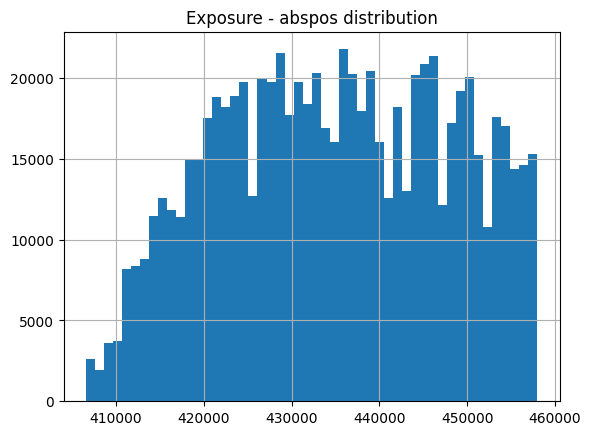

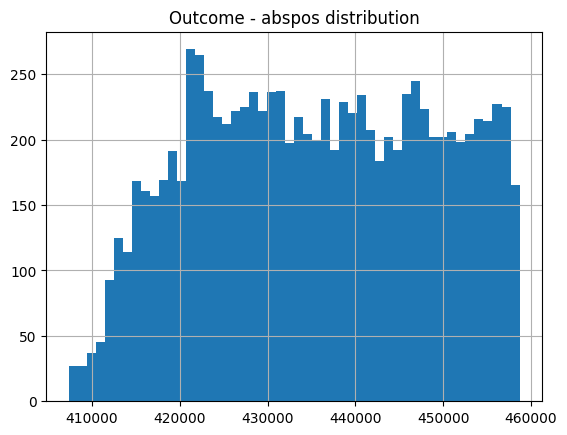

In [9]:
import matplotlib.pyplot as plt

exposure["abspos"].hist(bins=50)
plt.title("Exposure - abspos distribution")
plt.show()

outcome["abspos"].hist(bins=50)
plt.title("Outcome - abspos distribution")
plt.show()


In [11]:
common_subjects = set(exposure["subject_id"]).intersection(set(outcome["subject_id"]))
print(f"Number of common subjects: {len(common_subjects)}")


Number of common subjects: 9529


یشتر داده‌ها در سمت چپ جمع شدن → یعنی برای بیشتر افراد، فاصله‌ی زمانی بین 

exposure و outcome 

خیلی کم بوده، مثلاً 0 تا 50 روز.

بیشترین فراوانی در بازه‌ی خیلی کوچیکه (مثلاً 0 تا 50 روز)
→ این یعنی در اکثر موارد،
 outcome خیلی سریع بعد از exposure رخ داده.

یه دُم بلند به سمت راست داریم (right skewed)

→ این یعنی بعضی افراد فاصله‌ی خیلی طولانی‌تری داشتن (مثلاً حتی تا 2000 روز = ~5.5 سال)، ولی اون‌ها تعدادشون خیلی کمه.

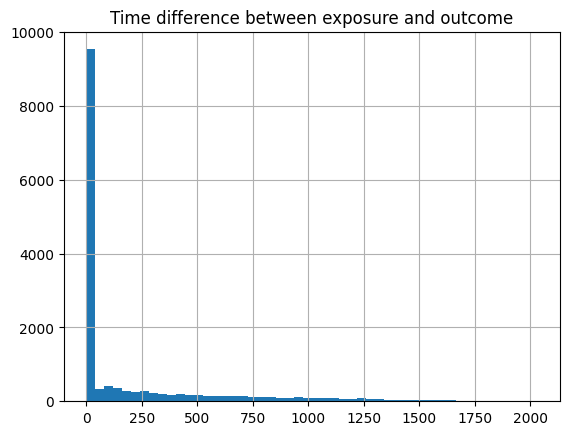

In [13]:
merged = pd.merge(exposure, outcome, on="subject_id", suffixes=("_exp", "_out"))
merged["delta_hours"] = merged["abspos_out"] - merged["abspos_exp"]
merged["delta_days"] = merged["delta_hours"] / 24
merged["delta_days"].hist(bins=50)
plt.title("Time difference between exposure and outcome")
plt.show()


بیشتر outcome

ها بلافاصله بعد از exposure

 اتفاق افتادن → احتمال وجود رابطه‌ی مستقیم یا علّی.

In [14]:
print(merged["delta_days"].value_counts().sort_index())


0.0          1
30.0      9530
60.0         7
61.0        20
62.0        23
          ... 
1958.0       1
1990.0       1
1993.0       1
2007.0       1
2031.0       1
Name: delta_days, Length: 1464, dtype: int64


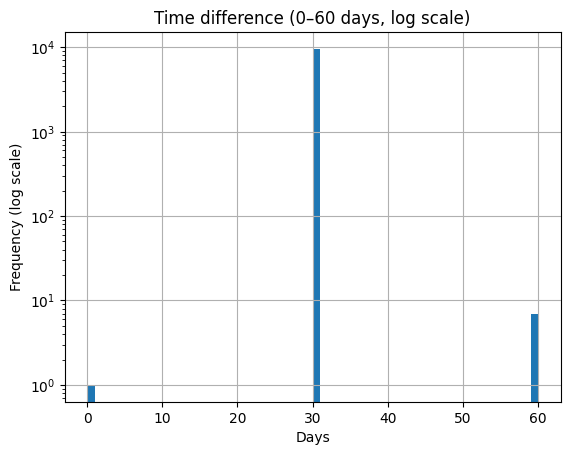

In [15]:
merged[(merged["delta_days"] >= 0) & (merged["delta_days"] <= 60)]["delta_days"].hist(bins=60)
plt.yscale('log')
plt.title("Time difference (0–60 days, log scale)")
plt.xlabel("Days")
plt.ylabel("Frequency (log scale)")
plt.grid(True)
plt.show()


In [22]:
print(merged["delta_days"].value_counts().sort_index())


0.0          1
30.0      9530
60.0         7
61.0        20
62.0        23
          ... 
1958.0       1
1990.0       1
1993.0       1
2007.0       1
2031.0       1
Name: delta_days, Length: 1464, dtype: int64


In [9]:

directory_path = "Zahra/CoreBehrt/MDP/2_CreateOutcome/Mortality"

# آپلود exposure
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/exposure_Mor_MDP.csv",
    remote_file_name="exposure.csv",
    credential=credential
)

# آپلود outcome
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/outcome_Mor_MDP.csv",
    remote_file_name="outcome.csv",
    credential=credential
)


Uploading file
 File Uploaded Successfully Zahra/CoreBehrt/MDP/2_CreateOutcome/Mortality/exposure.csv
Uploading file
 File Uploaded Successfully Zahra/CoreBehrt/MDP/2_CreateOutcome/Mortality/outcome.csv
